## 1. Librerías

In [18]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

from scipy.stats import randint, uniform  

import matplotlib.pyplot as plt

## 2. Carga y Procesamiento de Datos

In [19]:
# Carga y preprocesamiento de datos
df = pd.read_csv("../dataset_v2_fs_top60_+2.csv")

df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df = df.sort_values("fecha")

# Filtrar datos entre 2025-01-01 y 2025-04-30 (inclusive)
df = df[(df["fecha"] >= "2025-01-01") & (df["fecha"] <= "2025-04-30")]

# Renombrar columna target
df = df.rename(columns={"merval_apertura_+2": "merval"})

# Configurar índice temporal con frecuencia diaria
df.set_index("fecha", inplace=True)
df.index = df.index.to_period("D")

# Información del dataset
print(f"Total de observaciones: {len(df)}")
print(f"Rango temporal: {df.index.min()} a {df.index.max()}")

Total de observaciones: 79
Rango temporal: 2025-01-02 a 2025-04-30


In [20]:
# Verificar que no haya NAs en la variable objetivo
print(f"Filas con NA en 'merval': {df.loc[df['merval'].isna()].shape[0]}")
df = df.loc[df['merval'].notna()]

# Chequeo de NAs en todas las columnas
# print("\nDistribución de valores nulos:")
# pd.DataFrame({
#     'N': df.isna().sum(),
#     '%': round(df.isna().sum()/df.shape[0]*100, 1)
# })

Filas con NA en 'merval': 0


In [21]:
# Separación de variables predictoras y objetivo

y = df["merval"]
X = df.drop(columns=["merval"])

## 3. División Train-Test

In [22]:
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (63, 60)
Test shape: (16, 60)


## 4. Feature Selection - Selección de Top Features

In [23]:
# Entrenar un modelo simple para obtener importancia de features
# Usamos Random Forest con configuración conservadora
rf_selector = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

rf_selector.fit(X_train, y_train)

# Obtener importancia de features
feature_importance = pd.Series(
    rf_selector.feature_importances_, 
    index=X_train.columns
).sort_values(ascending=False)

print("\nTop 15 features más importantes:")
print(feature_importance.head(15))


Top 15 features más importantes:
merval_cierre                      0.181234
merval_apertura_std20              0.174297
tc_mayorista_std20                 0.119429
emae_tendencia_ciclo_ma_5          0.117334
badlar_ma_5                        0.071848
tc_minorista_std20                 0.060031
merval_cierre_std20                0.041002
tasa_prestamos_personales_ma_3     0.034160
badlar_ma_3                        0.023849
emae_tendencia_ciclo_lag2          0.020620
tasa_prestamos_personales_ma_5     0.019483
inflacion_hp_ema20                 0.015673
merval_maximo                      0.015642
tasa_prestamos_personales_std20    0.013007
m1_std20                           0.009247
dtype: float64


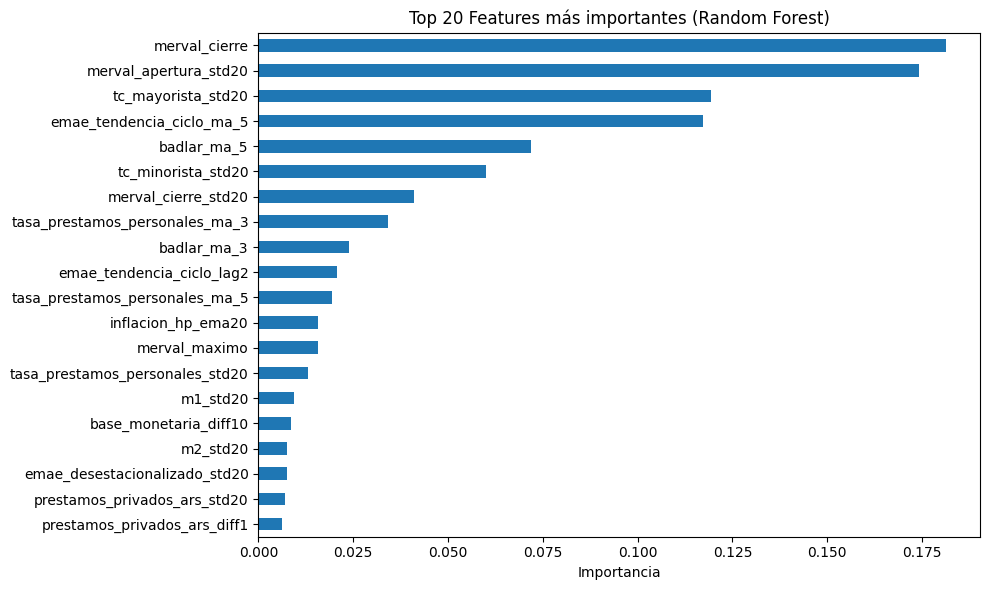

In [24]:
# Visualizar importancia de features
plt.figure(figsize=(10, 6))
feature_importance.head(20).sort_values(ascending=True).plot(kind='barh')
plt.title('Top 20 Features más importantes (Random Forest)')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

In [25]:
# Seleccionar top N features
# Probamos con 12 y 15 features para ver cuál funciona mejor
N_FEATURES = 12  # Cambiar a 15 si se desea probar con más features

selected_features = feature_importance.head(N_FEATURES).index.tolist()

print(f"\nSeleccionadas {N_FEATURES} features:")
for i, feat in enumerate(selected_features, 1):
    print(f"{i}. {feat}")

# Filtrar datasets
X_train_fs = X_train[selected_features]
X_test_fs = X_test[selected_features]

print(f"\nNuevo train shape: {X_train_fs.shape}")
print(f"Nuevo test shape: {X_test_fs.shape}")
print(f"\nNuevo ratio observaciones/features: {X_train_fs.shape[0] / X_train_fs.shape[1]:.2f}")


Seleccionadas 12 features:
1. merval_cierre
2. merval_apertura_std20
3. tc_mayorista_std20
4. emae_tendencia_ciclo_ma_5
5. badlar_ma_5
6. tc_minorista_std20
7. merval_cierre_std20
8. tasa_prestamos_personales_ma_3
9. badlar_ma_3
10. emae_tendencia_ciclo_lag2
11. tasa_prestamos_personales_ma_5
12. inflacion_hp_ema20

Nuevo train shape: (63, 12)
Nuevo test shape: (16, 12)

Nuevo ratio observaciones/features: 5.25


## 5. Optimización de Hiperparámetros con RandomizedSearchCV

In [26]:
# Con 63 días de entrenamiento, usamos configuración balanceada:
# - n_splits=3: tres validaciones suficientes con pocos datos
# - test_size=8: ventana pequeña de validación
# - gap=1: separación mínima para maximizar datos disponibles

max_lag = 1
test_size = 8
tscv = TimeSeriesSplit(n_splits=3, test_size=test_size, gap=max_lag)

In [27]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Parámetros balanceados para dataset pequeño
# Estrategia: permitir complejidad moderada pero con regularización
param_distributions = {
    "n_estimators": randint(150, 400),        # Suficientes árboles para estabilidad
    "max_depth": randint(8, 16),              # Profundidad moderada-alta
    "min_samples_split": randint(4, 12),      # Más flexible para aprovechar los datos
    "min_samples_leaf": randint(2, 6),        # Hojas pequeñas permitidas
    "max_features": uniform(0.4, 0.5),        # Rango centrado en valores típicos (0.4-0.9)
    "bootstrap": [True]
}

# Configuración de RandomizedSearchCV
search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=60,                               # Más iteraciones para explorar mejor
    scoring="neg_root_mean_squared_error",   # RMSE (negativo por convención de sklearn)
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True,                              # Reentrena con el mejor conjunto según scoring
    return_train_score=True,                 # Útil para auditar overfitting
    error_score=np.nan                       # Si algún fold falla, no aborta toda la búsqueda
)

In [28]:
search.fit(X_train_fs, y_train)

best_rf = search.best_estimator_

print("\n" + "="*50)
print("RESULTADOS DE LA OPTIMIZACIÓN")
print("="*50)
print(f"\nMejor CV RMSE: {-search.best_score_:.4f}")
print(f"\nMejores hiperparámetros:")
for param, value in search.best_params_.items():
    print(f"  - {param}: {value}")

Fitting 3 folds for each of 60 candidates, totalling 180 fits

RESULTADOS DE LA OPTIMIZACIÓN

Mejor CV RMSE: 109584.6884

Mejores hiperparámetros:
  - bootstrap: True
  - max_depth: 13
  - max_features: 0.7925879806965068
  - min_samples_leaf: 4
  - min_samples_split: 7
  - n_estimators: 204


## 6. Evaluación en Test Set

### 6.1. Test del mejor modelo

In [29]:
y_pred = best_rf.predict(X_test_fs)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse_rel = rmse / y_test.mean()

print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")
print(f"Error relativo (holdout): {rmse_rel:.2%}")

Holdout RMSE: 308424.8796
Holdout R²:   -12.0652
Error relativo (holdout): 14.15%


### 6.2. Visualización de predicciones

In [30]:
# Agregamos las predicciones al dataframe original (solo para las filas de test)
df.loc[y_test.index, "pred_merval"] = y_pred

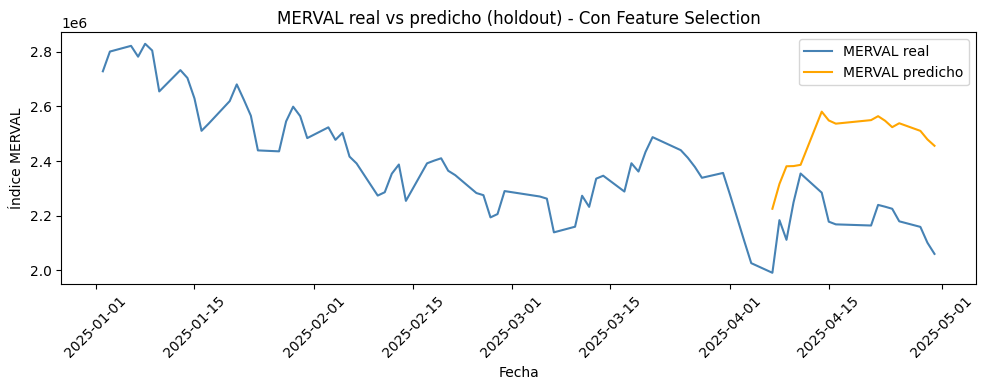

In [31]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df.index.to_timestamp(), df["merval"], label="MERVAL real", color="steelblue")
ax.plot(df.index.to_timestamp(), df["pred_merval"], label="MERVAL predicho", color="orange")

ax.set_title("MERVAL real vs predicho (holdout) - Con Feature Selection")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

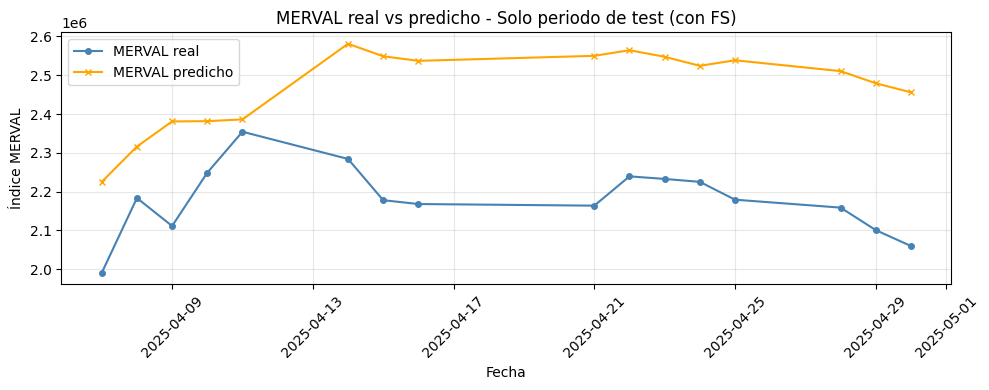

In [32]:
# Gráfico detallado solo para el periodo de test
df_test = df.loc[y_test.index]

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df_test.index.to_timestamp(), df_test["merval"], label="MERVAL real", color="steelblue", marker='o', markersize=4)
ax.plot(df_test.index.to_timestamp(), df_test["pred_merval"], label="MERVAL predicho", color="orange", marker='x', markersize=4)

ax.set_title("MERVAL real vs predicho - Solo periodo de test (con FS)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3. Análisis de residuales

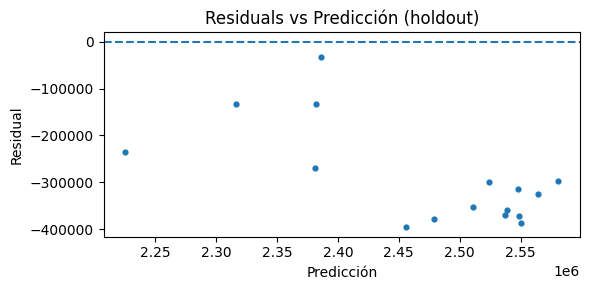

In [33]:
res = y_test - y_pred
plt.figure(figsize=(6,3))
plt.scatter(y_pred, res, s=12)
plt.axhline(0, ls="--")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.title("Residuals vs Predicción (holdout)")
plt.tight_layout(); plt.show()

### 6.4. Importancia de variables (features seleccionadas)

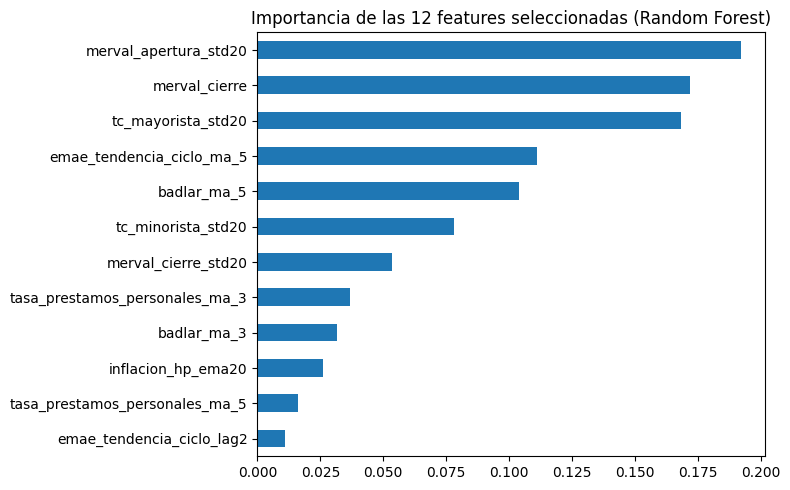

In [34]:
# Importancia de las variables seleccionadas

imp = pd.Series(best_rf.feature_importances_, index=X_train_fs.columns).sort_values(ascending=True)
imp.plot(kind="barh", figsize=(8,5), title=f"Importancia de las {N_FEATURES} features seleccionadas (Random Forest)")
plt.tight_layout(); plt.show()

## 7. Conclusiones

Este modelo utiliza **feature selection** para reducir el número de variables de 60 a 12, abordando el problema de la maldición de la dimensionalidad que afecta particularmente a este dataset pequeño de 4 meses.

### Resultados Principales

**Métricas de rendimiento:**
- **RMSE en CV**: 109,585
- **RMSE en Test**: 308,425
- **R² en Test**: -12.07
- **Error relativo**: 14.15%

**Configuración del modelo:**
- **Features utilizadas**: 12 (de 60 originales)
- **Ratio observaciones/features**: 5.25 (mejorado desde 1.05)
- **Observaciones de entrenamiento**: 63
- **Observaciones de test**: 16

### Análisis del Desempeño

#### 1. Overfitting Severo

El modelo presenta **overfitting severo** a pesar de la reducción de features:
- Gap CV→Test: +181% (RMSE casi triplica entre CV y Test)
- R² profundamente negativo (-12.07), indicando predicciones mucho peores que un modelo baseline que predice la media
- Error relativo del 14.15%, muy alto para aplicaciones financieras

#### 2. Limitación Fundamental: Datos Insuficientes

El problema principal **no es solo la dimensionalidad sino la escasez absoluta de datos**:
- Con solo 63 observaciones de entrenamiento, Random Forest no puede construir un ensemble robusto
- Aunque el ratio observaciones/features mejoró a 5.25, Random Forest típicamente necesita 100-300+ observaciones
- Cada árbol del bosque se entrena con una muestra bootstrap de solo ~63 observaciones, lo que lleva a alta varianza

#### 3. Features Seleccionadas

El proceso de feature selection identificó las siguientes 12 variables como más importantes:
1. merval_cierre (valor de cierre del índice)
2. merval_apertura_std20 (volatilidad de apertura)
3. tc_mayorista_std20 (volatilidad tipo de cambio mayorista)
4. emae_tendencia_ciclo_ma_5 (indicador de actividad económica)
5. badlar_ma_5 (promedio móvil tasa BADLAR)
6. tc_minorista_std20 (volatilidad tipo de cambio minorista)
7. merval_cierre_std20 (volatilidad del cierre)
8. tasa_prestamos_personales_ma_3 (tasa de préstamos)
9. badlar_ma_3 (BADLAR suavizada)
10. emae_tendencia_ciclo_lag2 (EMAE rezagado)
11. tasa_prestamos_personales_ma_5
12. inflacion_hp_ema20 (inflación filtrada)

**Interpretación económica**: El modelo prioriza features de **volatilidad del mercado** (std20 de MERVAL y tipo de cambio) y **variables monetarias** (tasas de interés, BADLAR). Esto tiene sentido ya que la volatilidad y condiciones crediticias son predictores naturales de movimientos del índice bursátil.

#### 4. Comportamiento en Validación vs Test

La discrepancia masiva CV-Test revela:
- TimeSeriesSplit con 3 folds no captura la verdadera variabilidad del test set
- El período de test (últimas ~2 semanas de abril) presenta dinámica diferente al entrenamiento
- 4 meses de historia son insuficientes para capturar regímenes de mercado diversos

### Hiperparámetros Óptimos Encontrados

RandomizedSearchCV encontró la siguiente configuración (60 iteraciones):
- **n_estimators**: 204 (árboles en el bosque)
- **max_depth**: 13 (árboles profundos)
- **max_features**: 0.79 (~9-10 features por split)
- **min_samples_split**: 7
- **min_samples_leaf**: 4
- **bootstrap**: True

**Análisis de hiperparámetros**: La configuración permite árboles relativamente profundos (max_depth=13) con splits conservadores (min_samples_split=7), buscando un balance entre capacidad y generalización. Sin embargo, con tan pocos datos, incluso configuraciones conservadoras generan overfitting.

### Comparación CV vs Test: Análisis del Gap

El gap de +181% entre CV (109k) y Test (308k) es **alarmante** y evidencia:
- **Sobreestimación del rendimiento**: El modelo parece funcionar razonablemente en CV pero falla completamente en test
- **Folds correlacionados**: Los 3 folds de CV comparten dinámica similar, mientras test presenta condiciones diferentes
- **Baja representatividad**: 4 meses de datos no cubren suficientes escenarios de mercado

### Limitaciones del Modelo

1. **Dataset demasiado pequeño**: 63 observaciones son claramente insuficientes para Random Forest
2. **Período temporal limitado**: 4 meses (ene-abr 2025) no capturan ciclos económicos completos
3. **Alta varianza entre folds**: El desempeño es extremadamente dependiente de la partición train/test
4. **Feature selection insuficiente**: Aunque mejoró el ratio, no resuelve el problema fundamental de escasez de datos
5. **Ensemble débil**: Con pocos datos, los árboles del bosque tienden a ser similares entre sí, reduciendo los beneficios del ensemble

### Comparación con Objetivo Inicial

**Hipótesis inicial**: Reducir features de 60 a 12 mejoraría la generalización y reduciría overfitting.

**Resultado**: La feature selection **no fue suficiente** para resolver el problema. Aunque el ratio observaciones/features mejoró significativamente (1.05 → 5.25), el modelo sigue presentando overfitting severo y performance inaceptable.

### Conclusión Final

**El modelo Random Forest con feature selection no es viable para este dataset.**

A pesar de haber:
- ✓ Reducido features de 60 a 12 (80% reducción)
- ✓ Mejorado ratio observaciones/features de 1.05 a 5.25
- ✓ Optimizado hiperparámetros con 60 iteraciones de búsqueda
- ✓ Usado regularización (min_samples_split, min_samples_leaf)

El modelo aún presenta:
- ✗ R² de -12.07 (peor que predecir la media constante)
- ✗ Gap CV-Test de +181%
- ✗ Error relativo del 14.15%

**Veredicto**: La limitación fundamental es la **cantidad absoluta de datos**, no solo la dimensionalidad. Random Forest requiere significativamente más observaciones (idealmente 200-300+) para funcionar correctamente. Con solo 63 observaciones, el modelo no puede construir un ensemble robusto que generalice a datos nuevos.

**La feature selection es una estrategia válida pero insuficiente cuando el dataset es fundamentalmente demasiado pequeño.**